In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.cluster import KMeans

iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width'
                                                , 'petal_length', 'petal_width'])
iris_df.head(20)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [10]:
km = KMeans(n_clusters=3, init='k-means++', max_iter=500, random_state=0)
km.fit(iris_df) # 훈련/테스트 구분 없음
km.labels_


c:\Apps\MiniConda\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [11]:
iris_df['target'] = iris.target
iris_df['cluster'] = km.labels_

iris_df.head(20)


,sepal_length,sepal_width,petal_length,petal_width,target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
5,5.4,3.9,1.7,0.4,0,1
6,4.6,3.4,1.4,0.3,0,1
7,5.0,3.4,1.5,0.2,0,1
8,4.4,2.9,1.4,0.2,0,1
9,4.9,3.1,1.5,0.1,0,1


In [12]:
iris_df.groupby(['target', 'cluster']).count()

sepal_length  sepal_width  petal_length  petal_width
target cluster                                                      
0      1                  50           50            50           50
1      0                  47           47            47           47
       2                   3            3             3            3
2      0                  14           14            14           14
       2                  36           36            36           36

# 군집의 평가 : 실루엣계수 (silhouette Coefficient)

In [18]:
from sklearn.metrics import silhouette_score, silhouette_samples

silhouette_score(iris.data, iris_df['cluster'])  # 전체 Sample에 대한 평균 실루엣 계수
iris_df['silhouette'] = silhouette_samples(iris.data, iris_df['cluster'])

iris_df.head()


,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette
0,5.1,3.5,1.4,0.2,0,1,0.852582
1,4.9,3.0,1.4,0.2,0,1,0.814916
2,4.7,3.2,1.3,0.2,0,1,0.828797
3,4.6,3.1,1.5,0.2,0,1,0.804352
4,5.0,3.6,1.4,0.2,0,1,0.848918


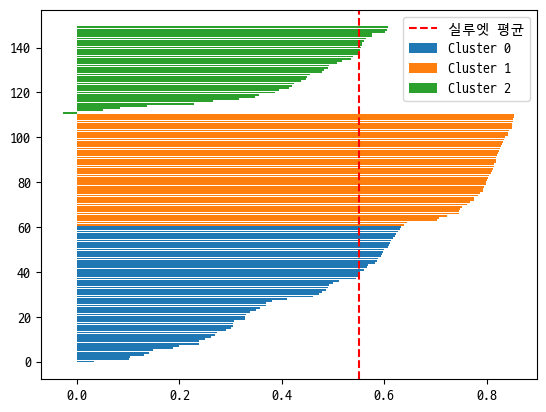

In [38]:
import matplotlib.pyplot as plt
# plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows
# plt.rcParams['font.family'] = 'AppleGothic'   # macOS
plt.rcParams['font.family'] = 'D2Coding'   # Linux(나눔폰트 설치 시)
plt.rcParams['axes.unicode_minus'] = False      # - 기호 깨짐 방지

y_lower = 0

for i in range(3) :
    cluster = iris_df[iris_df['cluster'] == i]['silhouette'].sort_values()
    
    y_upper = y_lower + len(cluster)
    
    plt.barh(range(y_lower, y_upper), cluster, label=f"Cluster {i}")
    
    y_lower = y_upper


# 평균선 그리기
avg_score = silhouette_score(iris.data, iris_df['cluster'])
plt.axvline(avg_score, color='red', linestyle='--', label='실루엣 평균')

plt.legend()
plt.show()


# K 값 선택을 위한 스크리 챠트

c:\Apps\MiniConda\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Apps\MiniConda\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Apps\MiniConda\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Apps\MiniConda\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a m

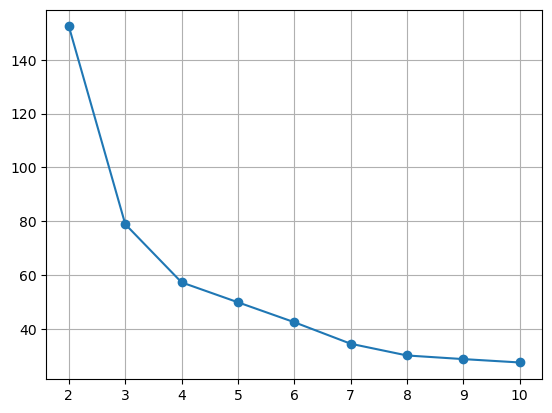

In [ ]:
# import
k_values = range(2, 11)
sse_values = []

scree_df = iris_df.drop(columns=['target', 'cluster', 'silhouette'])

for i in k_values :
    kmi = KMeans(n_clusters=i, init='k-means++', max_iter=300, random_state=0)
    kmi.fit(scree_df)
    
    sse_values.append(kmi.inertia_)
    
sse_values

plt.plot(k_values, sse_values, marker='o')
plt.grid()
plt.show()